# Prova de Conceito — xCounter com Atributos Físicos do Football Manager

**Disciplina:** COE609 - Ciência de Dados Aplicada ao Futebol (UFRJ, 2026.1)

## Objetivo

Construir um modelo preditivo de sucesso de contra-ataques (**xCounter**) substituindo
features físicas de tracking contínuo por um *prior* estático de atributos por jogador
extraído do **Football Manager 2023**.

**Hipótese central:** essa substituição preserva poder preditivo significativo, viabilizando
a metodologia em contextos sem tracking caro.

## Partida analisada

Copa do Mundo FIFA 2022 — **País de Gales × Irã** (`match_id = 3857273`)

## Pipeline resumido

| Etapa | Descrição |
|-------|-----------|
| 1 | Carregamento dos dados (eventos + StatsBomb 360) |
| 2 | Identificação de cadeias de contra-ataque |
| 3 | Extração de features espaciais do freeze frame 360 |
| 4 | Integração com Football Manager 2023 |
| 5 | Visualizações de validação |

---
**Referências:**
- Biermann et al. (2023, 2024) — *Towards Expected Counter / Quantification of Turnover Danger*
- Sahasrabudhe & Bekkers (2023, MIT Sloan) — *GNN for Counterattacks*
- Fernández et al. (2019, MIT Sloan) — *Decomposing the Immeasurable Sport*

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import re
import os

from mplsoccer import Sbopen, Pitch
from unidecode import unidecode

print("Bibliotecas carregadas com sucesso.")
import mplsoccer
print(f"  pandas {pd.__version__} | numpy {np.__version__} | mplsoccer {mplsoccer.__version__}")

Bibliotecas carregadas com sucesso.
  pandas 2.2.3 | numpy 2.1.3 | mplsoccer 1.6.1


## Parâmetros do Pipeline

Todos os critérios operacionais estão centralizados aqui para facilitar ajustes e reprodutibilidade.

In [2]:
# ==================
# PARÂMETROS GLOBAIS
# ==================
MATCH_ID       = 3857273   # Copa do Mundo 2022: País de Gales × Irã
COMPETITION_ID = 43        # FIFA World Cup
SEASON_ID      = 106       # 2022

GOAL_X = 120.0  # Coordenada x do gol adversário (sistema StatsBomb: 0-120)
GOAL_Y = 40.0   # Coordenada y do centro do gol

# Atributos físicos do FM2023 a incorporar
FM_ATTRS    = ['Pac', 'Acc', 'Sta', 'Str', 'Agi', 'Bal', 'Jum']
FM_CSV_PATH = 'fm2023.csv'

# ============================================================
# BLOCO DE CONFIGURAÇÃO — xCounter
# Altere apenas aqui para análise de sensibilidade.
# Não toque no corpo das funções.
# ============================================================
config = {
    # --- Zona de início válida para a recuperação ---
    # Opções: "metade_defensiva" (x < 60), "terco_defensivo" (x < 40),
    #         "campo_todo" (qualquer x), "custom" (x < zona_recuperacao_x_max)
    # Sistema de coordenadas StatsBomb: eixo x de 0 a 120; equipe que
    # recupera ataca em direção a x=120.
    "zona_recuperacao":       "metade_defensiva",
    "zona_recuperacao_x_max": None,  # usado só se zona_recuperacao == "custom"

    # --- Janela de análise pós-recuperação ---
    "max_eventos_apos":          5,   # eventos a olhar após a recuperação (5→original)
    "max_tempo_s":               15,  # duração máxima da cadeia em segundos
    "progressao_vertical_min_m": 30,  # ganho mínimo em x (metros) para qualificar

    # --- Condições de quebra da cadeia (avaliadas nesta ordem) ---
    # 1. fim_periodo: period do próx. evento != period do início da cadeia
    # 2. perda_posse: equipe do próx. evento != equipe recuperadora
    # 3. max_tempo_s / max_eventos_apos: sempre verificados (não são flags)
    # 4. falta: próx. evento é Foul Won ou Foul Committed (depois de adicionar)
    # 5. chute: próx. evento é Shot (depois de adicionar)
    "quebrar_em_fim_periodo":  False,  # False → comportamento original
    "quebrar_em_perda_posse":  True,
    "quebrar_em_falta":        False,  # False → comportamento original
    "quebrar_em_chute":        True,

    # --- Eventos que iniciam um contra-ataque ---
    "eventos_inicio": ["Ball Recovery", "Interception", "Duel"],

    # --- Critério de sucesso ---
    # "qualquer_chute" : sucesso se a cadeia termina em qualquer Shot
    # "xg_threshold"   : sucesso se Shot com shot_statsbomb_xg >= xg_threshold
    # "gol"            : sucesso somente se o Shot resultou em gol
    "criterio_sucesso": "xg_threshold",
    "xg_threshold":     0.10,
}


def validar_config(cfg):
    """Valida parâmetros do config; levanta ValueError com mensagem clara."""
    zonas_validas = {"metade_defensiva", "terco_defensivo", "campo_todo", "custom"}
    if cfg["zona_recuperacao"] not in zonas_validas:
        raise ValueError(f"zona_recuperacao deve ser uma de {zonas_validas}.")
    if cfg["zona_recuperacao"] == "custom" and cfg.get("zona_recuperacao_x_max") is None:
        raise ValueError("zona_recuperacao='custom' requer zona_recuperacao_x_max != None.")
    criterios_validos = {"qualquer_chute", "xg_threshold", "gol"}
    if cfg["criterio_sucesso"] not in criterios_validos:
        raise ValueError(f"criterio_sucesso deve ser um de {criterios_validos}.")
    if cfg["criterio_sucesso"] == "xg_threshold" and cfg.get("xg_threshold") is None:
        raise ValueError("criterio_sucesso='xg_threshold' requer xg_threshold definido.")


validar_config(config)

# Aliases para compatibilidade com as células de visualização
XG_THRESHOLD             = config["xg_threshold"]
CRIT_TEMPO_MAX_S         = config["max_tempo_s"]
CRIT_DIST_VERTICAL_MIN_M = config["progressao_vertical_min_m"]
CRIT_MAX_EVENTOS         = config["max_eventos_apos"]

print("Parâmetros configurados e validados.")
print(f"  Match ID: {MATCH_ID} | Zona: {config['zona_recuperacao']} | "
      f"xG threshold: {XG_THRESHOLD}")
print(f"  Tempo máx: {CRIT_TEMPO_MAX_S}s | Progressão mín: "
      f"{CRIT_DIST_VERTICAL_MIN_M}m | Eventos máx pós-rec.: {CRIT_MAX_EVENTOS}")


Parâmetros configurados e validados.
  Match ID: 3857273 | Zona: metade_defensiva | xG threshold: 0.1
  Tempo máx: 15s | Progressão mín: 30m | Eventos máx pós-rec.: 5


## Etapa 1 — Carregamento dos Dados

Carregamos os dados via `mplsoccer.Sbopen`:

- `parser.event(match_id)` → 4 DataFrames: eventos, relacionados, freeze de chutes, táticas
- `parser.frame(match_id)` → 2 DataFrames: `df_360` (posições por evento) e `df_visible` (área rastreada)

O `df_360` tem colunas `[teammate, actor, keeper, match_id, id, x, y]` — uma linha por jogador
visível em cada evento com cobertura 360.

In [3]:
print("=== Etapa 1: Carregamento dos Dados ===\n")
parser = Sbopen()

# Eventos e táticas
df_event, df_related, df_freeze_shots, df_tactics = parser.event(MATCH_ID)

# Freeze frames 360 de todos os eventos com cobertura
df_360, df_visible = parser.frame(MATCH_ID)

# Metadados da partida
df_match_info = parser.match(competition_id=COMPETITION_ID, season_id=SEASON_ID)
match_row     = df_match_info[df_match_info['match_id'] == MATCH_ID].iloc[0]

home_team  = match_row['home_team_name']
away_team  = match_row['away_team_name']
home_score = int(match_row['home_score'])
away_score = int(match_row['away_score'])

print(f"Partida:  {home_team}  {home_score} x {away_score}  {away_team}")
print(f"Data:     {str(match_row['match_date'])[:10]}")
print(f"\nEventos carregados:          {len(df_event):,}")
print(f"Linhas no DataFrame 360:     {len(df_360):,}")
print(f"Eventos com frame 360:       {df_360['id'].nunique():,}")
print(f"\nTipos de evento mais comuns:")
print(df_event['type_name'].value_counts().head(20).to_string())

=== Etapa 1: Carregamento dos Dados ===

Partida:  Wales  0 x 2  Iran
Data:     2022-11-25

Eventos carregados:          3,133
Linhas no DataFrame 360:     42,319
Eventos com frame 360:       2,768

Tipos de evento mais comuns:
type_name
Pass               922
Ball Receipt       760
Carry              645
Pressure           251
Ball Recovery      120
Duel                70
Clearance           51
Block               46
Goal Keeper         38
Shot                31
Miscontrol          28
Dribble             27
Interception        25
Foul Committed      19
Foul Won            19
Dispossessed        16
Dribbled Past       13
Injury Stoppage     10
Substitution         9
50/50                8


## Etapa 2 — Identificação de Cadeias de Contra-Ataque

Uma cadeia é classificada como **contra-ataque** se atende simultaneamente a:

| Critério | Parâmetro |
|----------|-----------|
| Início: Ball Recovery, Interception ou Duel vencido | `x < 60` (campo defensivo/médio-defensivo) |
| Duração máxima | `CRIT_TEMPO_MAX_S = 15s` |
| Progressão mínima no eixo x | `CRIT_DIST_VERTICAL_MIN_M = 30m` |
| Nº máximo de eventos | `CRIT_MAX_EVENTOS = 5` |

**Rótulo binário:**
- `sucesso = 1` → cadeia termina em chute com `shot_statsbomb_xg ≥ XG_THRESHOLD`
- `sucesso = 0` → caso contrário (inclui cadeias sem finalização)

In [4]:
# ============================================================
# ETAPA 2: IDENTIFICAÇÃO DE CONTRA-ATAQUES
# ============================================================

def _resolver_x_max_zona(cfg):
    """Traduz zona_recuperacao para o limite numérico em x."""
    zona = cfg["zona_recuperacao"]
    if zona == "metade_defensiva":
        return 60.0
    if zona == "terco_defensivo":
        return 40.0
    if zona == "campo_todo":
        return float("inf")
    return float(cfg["zona_recuperacao_x_max"])  # custom


def identificar_contra_ataques(df_event, cfg):
    """
    Identifica cadeias de contra-ataque a partir do dataframe de eventos.
    Recebe `cfg` (dict de config) com todos os critérios operacionais.

    Ordem de avaliação das condições de quebra do loop interno:
      ANTES de adicionar o evento à cadeia:
        1. quebrar_em_fim_periodo  — period diferente do início
        2. quebrar_em_perda_posse  — equipe diferente da recuperadora
        3. max_tempo_s             — sempre verificado
      APÓS adicionar o evento à cadeia:
        4. quebrar_em_falta        — Foul Won / Foul Committed
        5. quebrar_em_chute        — Shot

    Retorna lista de dicts com metadados de cada cadeia qualificada.
    """
    x_max_zona       = _resolver_x_max_zona(cfg)
    max_eventos      = cfg["max_eventos_apos"]
    max_tempo        = cfg["max_tempo_s"]
    prog_min         = cfg["progressao_vertical_min_m"]
    eventos_inicio   = set(cfg["eventos_inicio"])
    criterio_sucesso = cfg["criterio_sucesso"]
    xg_thr           = cfg.get("xg_threshold", 0.10)

    contra_ataques = []
    df = df_event.sort_values(["period", "minute", "second", "index"]).reset_index(drop=True)

    i = 0
    while i < len(df):
        ev    = df.iloc[i]
        x_ev  = ev.get("x")
        if pd.isna(x_ev):
            i += 1
            continue

        eh_rec  = ev["type_name"] in eventos_inicio
        na_zona = float(x_ev) < x_max_zona

        # Duels: apenas se foram vencidos
        if ev["type_name"] == "Duel":
            outcome = str(ev.get("outcome_name", "")).lower()
            eh_rec  = "won" in outcome

        if eh_rec and na_zona:
            t0        = ev["minute"] * 60 + ev["second"]
            equipe    = ev["team_name"]
            period_ev = ev["period"]
            cadeia    = [ev]

            j = i + 1
            while j < len(df) and len(cadeia) <= max_eventos:
                prox = df.iloc[j]
                t    = prox["minute"] * 60 + prox["second"]

                # Condições de quebra ANTES de adicionar (ordem 1 → 3)
                if cfg["quebrar_em_fim_periodo"] and prox["period"] != period_ev:
                    break
                if cfg["quebrar_em_perda_posse"] and prox["team_name"] != equipe:
                    break
                if (t - t0) > max_tempo:
                    break

                cadeia.append(prox)
                j += 1

                # Condições de quebra APÓS adicionar (ordem 4 → 5)
                if cfg["quebrar_em_falta"] and prox["type_name"] in {"Foul Won", "Foul Committed"}:
                    break
                if cfg["quebrar_em_chute"] and prox["type_name"] == "Shot":
                    break

            # Calcular métricas da cadeia
            x_ini   = float(ev["x"])
            ultimo  = cadeia[-1]
            x_fim   = ultimo.get("end_x")
            if pd.isna(x_fim):
                x_fim = ultimo.get("x", x_ini)
            x_fim   = float(x_fim) if not pd.isna(x_fim) else x_ini

            prog           = x_fim - x_ini
            terminou_chute = (ultimo["type_name"] == "Shot")
            xg_final       = float(ultimo.get("shot_statsbomb_xg") or 0) if terminou_chute else 0.0
            t_final        = ultimo["minute"] * 60 + ultimo["second"]
            duracao_s      = float(t_final - t0)

            # Critério de sucesso
            if criterio_sucesso == "qualquer_chute":
                sucesso = terminou_chute
            elif criterio_sucesso == "gol":
                sucesso = terminou_chute and str(ultimo.get("outcome_name", "")).lower() == "goal"
            else:  # xg_threshold
                sucesso = bool(terminou_chute and xg_final >= xg_thr)

            if prog >= prog_min:
                contra_ataques.append({
                    "id_inicio":      cadeia[0]["id"],
                    "player_id":      cadeia[0].get("player_id"),
                    "player_name":    str(cadeia[0].get("player_name", "")),
                    "team":           equipe,
                    "period":         int(cadeia[0]["period"]),
                    "minute":         int(cadeia[0]["minute"]),
                    "second":         int(cadeia[0]["second"]),
                    "tipo_inicio":    cadeia[0]["type_name"],
                    "x_inicio":       x_ini,
                    "y_inicio":       float(cadeia[0].get("y") or 40.0),
                    "num_eventos":    len(cadeia),
                    "progressao_x":   float(prog),
                    "duracao_s":      duracao_s,
                    "terminou_chute": terminou_chute,
                    "xg_final":       xg_final,
                    "sucesso":        bool(sucesso),
                })
        i += 1

    return contra_ataques


print("Funções _resolver_x_max_zona e identificar_contra_ataques definidas.")


Funções _resolver_x_max_zona e identificar_contra_ataques definidas.


In [5]:
contra_ataques = identificar_contra_ataques(df_event, config)
df_ca = pd.DataFrame(contra_ataques)

print(f"Contra-ataques identificados: {len(df_ca)}")
if len(df_ca) > 0:
    print(f"Taxa de sucesso geral:        {df_ca['sucesso'].mean():.1%}")
    print(f"\nPor equipe:")
    print(df_ca.groupby('team').agg(
        n_ca=('sucesso','count'),
        com_sucesso=('sucesso','sum'),
        taxa=('sucesso','mean')
    ).round(2).to_string())
    print(f"\nEstatísticas descritivas:")
    print(df_ca[['num_eventos','progressao_x','duracao_s','xg_final']].describe().round(2).to_string())
    print(f"\nLista completa de contra-ataques:")
    cols = ['team','period','minute','second','tipo_inicio',
            'num_eventos','progressao_x','duracao_s','terminou_chute','xg_final','sucesso']
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 160)
    print(df_ca[cols].to_string(index=False))
else:
    print("AVISO: Nenhum contra-ataque identificado com os critérios atuais.")
    print("Sugestão: reduzir progressao_vertical_min_m ou aumentar max_tempo_s.")


Contra-ataques identificados: 26
Taxa de sucesso geral:        3.8%

Por equipe:
       n_ca  com_sucesso  taxa
team                          
Iran     17            1  0.06
Wales     9            0  0.00

Estatísticas descritivas:
       num_eventos  progressao_x  duracao_s  xg_final
count        26.00         26.00      26.00     26.00
mean          4.58         57.42       6.85      0.01
std           1.58         21.16       4.14      0.04
min           2.00         31.00       0.00      0.00
25%           3.00         40.80       4.00      0.00
50%           5.50         52.85       6.00      0.00
75%           6.00         72.42      10.00      0.00
max           6.00        102.90      15.00      0.20

Lista completa de contra-ataques:
 team  period  minute  second   tipo_inicio  num_eventos  progressao_x  duracao_s  terminou_chute  xg_final  sucesso
Wales       1       3      50 Ball Recovery            6          45.4        9.0           False  0.000000    False
Wales       1

## Análise de Sensibilidade

A função `rodar_analise_sensibilidade` roda o pipeline de identificação para
múltiplas configurações e retorna um DataFrame comparativo — uma linha por config.

**Colunas do resultado:**
`zona_recuperacao`, `max_eventos`, `max_tempo_s`, `prog_min_m`,
`criterio_sucesso`, `n_contra_ataques`, `n_sucessos`, `taxa_sucesso`, `duracao_media_s`

> **Quando usar:** antes de escalar para todas as partidas da competição,
> use esta função numa partida de referência para entender como as escolhas
> de definição afetam a contagem e a taxa de sucesso dos contra-ataques.


In [6]:
# ============================================================
# FUNÇÃO: rodar_analise_sensibilidade
# ============================================================

def rodar_analise_sensibilidade(lista_configs, match_ids):
    """
    Roda identificar_contra_ataques para várias configs e várias partidas.

    Parâmetros
    ----------
    lista_configs : list[dict]  — configs a comparar (cada uma validada internamente)
    match_ids     : list[int]   — IDs das partidas a analisar

    Retorna
    -------
    pd.DataFrame com uma linha por config:
        config_idx, zona_recuperacao, max_eventos, max_tempo_s, prog_min_m,
        criterio_sucesso, n_contra_ataques, n_sucessos, taxa_sucesso, duracao_media_s
    """
    resultados = []
    for idx_cfg, cfg in enumerate(lista_configs):
        validar_config(cfg)
        n_ca, n_suc = 0, 0
        duracoes = []

        for mid in match_ids:
            df_ev, _, _, _ = parser.event(mid)
            cas = identificar_contra_ataques(df_ev, cfg)
            n_ca  += len(cas)
            n_suc += sum(c["sucesso"] for c in cas)
            duracoes.extend(c["duracao_s"] for c in cas)

        taxa      = n_suc / n_ca if n_ca > 0 else float("nan")
        dur_media = sum(duracoes) / len(duracoes) if duracoes else float("nan")

        resultados.append({
            "config_idx":       idx_cfg,
            "zona_recuperacao":  cfg["zona_recuperacao"],
            "max_eventos":       cfg["max_eventos_apos"],
            "max_tempo_s":       cfg["max_tempo_s"],
            "prog_min_m":        cfg["progressao_vertical_min_m"],
            "criterio_sucesso":  cfg["criterio_sucesso"],
            "n_contra_ataques":  n_ca,
            "n_sucessos":        n_suc,
            "taxa_sucesso":      round(taxa, 4),
            "duracao_media_s":   round(dur_media, 2),
        })

    return pd.DataFrame(resultados)


print("Função rodar_analise_sensibilidade definida.")


Função rodar_analise_sensibilidade definida.


## Etapa 3 — Features Espaciais do Freeze Frame 360

Para cada cadeia de contra-ataque, recuperamos o freeze frame do evento de início e calculamos:

| Feature | Cálculo |
|---------|---------|
| `dist_gol_defensor_proximo` | Dist. Euclidiana: gol → defensor mais avançado (maior `x` entre oponentes) |
| `dist_gol_atacante_avancado` | Dist. Euclidiana: gol → atacante mais avançado (maior `x` entre companheiros) |
| `diferencial_profundidade` | `x_atacante_avancado − x_defensor_mais_avancado` |
| `num_defensores_entre_bola_gol` | Oponentes com `x > x_bola` |
| `largura_linha_defensiva` | Spread em `y` dos 3 defensores mais avançados |
| `dist_bola_gol` | Distância Euclidiana da bola ao gol no instante da recuperação |
| `superioridade_terco_ofensivo` | `(companheiros com x > 80) − (oponentes com x > 80)` |

> **Nota técnica:** No `df_360`, `teammate=True` indica companheiros do jogador que executou o
> evento — ou seja, os *atacantes* no contexto do contra-ataque. Os jogadores são **anônimos**
> no freeze frame (sem `player_id`). A identidade vem do `df_event`.

In [7]:
# ============================================================
# ETAPA 3: FEATURES ESPACIAIS DO FREEZE FRAME 360
# ============================================================

def dist_eucl(x, y, x0=GOAL_X, y0=GOAL_Y):
    """Distância Euclidiana de (x, y) ao gol adversário (x=120, y=40)."""
    return float(np.sqrt((x - x0)**2 + (y - y0)**2))


def extrair_features_espaciais(event_id, df_event, df_360):
    """
    Extrai features espaciais do freeze frame 360 de um evento.
    Retorna dict com as 7 features ou None se o frame não estiver disponível.
    """
    ev = df_event[df_event["id"] == event_id]
    if ev.empty:
        return None
    ev = ev.iloc[0]

    frame = df_360[df_360["id"] == event_id]
    if frame.empty:
        return None

    bola_x = ev.get("x")
    bola_y = ev.get("y")
    if bola_x is None or pd.isna(bola_x):
        return None
    bola_x, bola_y = float(bola_x), float(bola_y)

    # teammate=True  → companheiros do recuperador (atacantes no CA)
    # teammate=False → adversários (defensores)
    tm = frame[frame["teammate"] == True].copy()
    op = frame[frame["teammate"] == False].copy()

    if len(op) < 1 or len(tm) < 1:
        return None

    # Defensor mais avançado
    x_def_av = float(op["x"].max())
    y_def_av = float(op.loc[op["x"].idxmax(), "y"])

    # Atacante mais avançado
    x_atac_av = float(tm["x"].max())
    y_atac_av = float(tm.loc[tm["x"].idxmax(), "y"])

    # Defensores entre bola e gol
    n_def_entre = int((op["x"] > bola_x).sum())

    # Largura da linha defensiva (3 mais avançados)
    top3 = op.nlargest(min(3, len(op)), "x")
    largura = float(top3["y"].max() - top3["y"].min()) if len(top3) >= 2 else 0.0

    # Superioridade no terço ofensivo
    sup_of = int((tm["x"] > 80).sum()) - int((op["x"] > 80).sum())

    return {
        "event_id":                      event_id,
        "dist_gol_defensor_proximo":     dist_eucl(x_def_av, y_def_av),
        "dist_gol_atacante_avancado":    dist_eucl(x_atac_av, y_atac_av),
        "diferencial_profundidade":      x_atac_av - x_def_av,
        "num_defensores_entre_bola_gol": n_def_entre,
        "largura_linha_defensiva":       largura,
        "dist_bola_gol":                 dist_eucl(bola_x, bola_y),
        "superioridade_terco_ofensivo":  sup_of,
    }

In [8]:
print("Extraindo features espaciais dos freeze frames 360...\n")

feat_rows, sem_frame = [], 0
for ca in contra_ataques:
    feats = extrair_features_espaciais(ca["id_inicio"], df_event, df_360)
    if feats is not None:
        feat_rows.append(feats)
    else:
        sem_frame += 1

df_feats = pd.DataFrame(feat_rows)
print(f"Cadeias com freeze frame: {len(df_feats)} / {len(contra_ataques)}")
print(f"Sem freeze frame:         {sem_frame}")

if len(df_feats) > 0:
    print("\nEstatísticas das features espaciais:")
    print(df_feats.drop(columns='event_id').describe().round(2).to_string())

# Unir metadados + features espaciais
df_dataset = (pd.DataFrame(contra_ataques)
              .merge(df_feats.rename(columns={"event_id": "id_inicio"}),
                     on="id_inicio", how="inner"))

print(f"\nDataset após Etapa 3: {len(df_dataset)} linhas × {len(df_dataset.columns)} colunas")

Extraindo features espaciais dos freeze frames 360...

Cadeias com freeze frame: 25 / 26
Sem freeze frame:         1

Estatísticas das features espaciais:
       dist_gol_defensor_proximo  dist_gol_atacante_avancado  diferencial_profundidade  num_defensores_entre_bola_gol  largura_linha_defensiva  dist_bola_gol  superioridade_terco_ofensivo
count                      25.00                       25.00                     25.00                          25.00                    25.00          25.00                          25.0
mean                       84.42                       85.76                     -1.69                           3.88                    27.33         103.65                           0.0
std                        13.57                       14.77                      8.17                           1.67                    12.51          15.40                           0.0
min                        58.77                       49.72                    -16.66       

## Etapa 4 — Integração com Football Manager 2023

> ### ⚠️ Simplificações documentadas
>
> 1. **Atacante:** o `player_name` vem diretamente do evento de início da cadeia (disponível em `df_event`).
>
> 2. **Defensor proxy:** como o freeze frame 360 não contém `player_id`, usa-se o primeiro
>    jogador adversário com posição defensiva (CB, LB, RB) da **escalação tática inicial**.
>    Esse proxy é **fixo para todos os contra-ataques** de uma equipe — limitação a corrigir na Etapa (c) dos Próximos Passos.
>
> 3. **Casamento de nomes:** via unidecode + lowercase + múltiplas estratégias de substring.
>    Nomes compostos StatsBomb (ex.: "Lionel Andrés Messi Cuccittini") são decompostos para encontrar
>    a entrada FM2023 correspondente ("Lionel Messi").

### Atributos físicos incorporados
`Pace (Pac)`, `Acceleration (Acc)`, `Stamina (Sta)`, `Strength (Str)`,
`Agility (Agi)`, `Balance (Bal)`, `Jumping Reach (Jum)`

In [9]:
# ============================================================
# ETAPA 4A: CARREGAMENTO DO FM2023 + LINEUP
# ============================================================

def norm_nome(nome):
    """Normaliza nome: unidecode + lowercase + remove não-letras + sufixos."""
    nome = unidecode(str(nome)).lower()
    nome = re.sub(r'[^a-z\s]', '', nome)
    nome = re.sub(r'\b(jr|sr|ii|iii|iv)\b', '', nome)
    return re.sub(r'\s+', ' ', nome).strip()


# Mapeamento StatsBomb country_name → código FM2023 (Nat).
# Construído a partir dos 32 country_names únicos presentes nas lineups
# da Copa do Mundo FIFA 2022 (competition_id=43, season_id=106).
# Casos não-óbvios: '\xa0' = non-breaking space no dado fonte (Korea).
COUNTRY_TO_FM = {
    'Argentina':                 'ARG',
    'Australia':                 'AUS',
    'Belgium':                   'BEL',
    'Brazil':                    'BRA',
    'Cameroon':                  'CMR',
    'Canada':                    'CAN',
    'Costa Rica':                'CRC',
    'Croatia':                   'CRO',
    'Denmark':                   'DEN',
    'Ecuador':                   'ECU',
    'England':                   'ENG',
    'France':                    'FRA',
    'Germany':                   'GER',
    'Ghana':                     'GHA',
    'Iran, Islamic Republic of': 'IRN',
    'Japan':                     'JPN',
    'Korea\xa0(South)':          'KOR',
    'Mexico':                    'MEX',
    'Morocco':                   'MAR',
    'Netherlands':               'NED',
    'Poland':                    'POL',
    'Portugal':                  'POR',
    'Qatar':                     'QAT',
    'Saudi Arabia':              'KSA',
    'Senegal':                   'SEN',
    'Serbia':                    'SRB',
    'Spain':                     'ESP',
    'Switzerland':               'SUI',
    'Tunisia':                   'TUN',
    'United States of America':  'USA',
    'Uruguay':                   'URU',
    'Wales':                     'WAL',
}

df_fm = None

if os.path.exists(FM_CSV_PATH):
    print(f"Carregando FM2023: {FM_CSV_PATH}")
    df_fm = pd.read_csv(FM_CSV_PATH, encoding='utf-8')
    df_fm.columns = [c.strip() for c in df_fm.columns]
    for col in df_fm.select_dtypes('object').columns:
        df_fm[col] = df_fm[col].astype(str).str.strip()
    for attr in FM_ATTRS:
        df_fm[attr] = pd.to_numeric(df_fm[attr], errors='coerce')
    df_fm['name_norm'] = df_fm['Name'].apply(norm_nome)

    # Parsear DoB: "DD/M/YYYY (N years old)" → "YYYY-MM-DD"
    def _parse_dob(dob_str):
        m = re.match(r'(\d{1,2})/(\d{1,2})/(\d{4})', str(dob_str))
        return f"{m.group(3)}-{int(m.group(2)):02d}-{int(m.group(1)):02d}" if m else None
    df_fm['DoB_parsed'] = df_fm['DoB'].apply(_parse_dob)

    n_dob = df_fm['DoB_parsed'].notna().sum()
    print(f"  Jogadores carregados : {len(df_fm):,}")
    print(f"  DoB_parsed preenchido: {n_dob:,} / {len(df_fm):,}")
    for q in ['lionel messi', 'kylian mbappe', 'cristiano ronaldo']:
        r = df_fm[df_fm['name_norm'].str.contains(q, na=False)]
        if len(r) > 0:
            row = r.iloc[0]
            print(f"  Verificação — {q}: Pac={row['Pac']}, DoB_parsed={row['DoB_parsed']}")

# --- Lineup: player_id → código FM de nacionalidade ---
print(f"\nCarregando lineup da partida {MATCH_ID}...")
df_lineup = parser.lineup(MATCH_ID)

nat_fm_por_player = (
    df_lineup
    .assign(nat_fm=df_lineup['country_name'].map(COUNTRY_TO_FM))
    .set_index('player_id')['nat_fm']
    .to_dict()
)

n_mapeados = sum(1 for v in nat_fm_por_player.values() if pd.notna(v))
print(f"  Jogadores no lineup      : {len(df_lineup)}")
print(f"  Nac. mapeadas para FM    : {n_mapeados} / {len(nat_fm_por_player)}")

paises_nao_mapeados = (df_lineup[~df_lineup['country_name'].isin(COUNTRY_TO_FM)]
                       ['country_name'].dropna().unique())
if len(paises_nao_mapeados):
    print(f"  AVISO — country_names sem mapeamento: {paises_nao_mapeados.tolist()}")

Carregando FM2023: fm2023.csv
  Jogadores carregados : 189,345
  DoB_parsed preenchido: 189,345 / 189,345
  Verificação — lionel messi: Pac=15, DoB_parsed=1987-06-24
  Verificação — kylian mbappe: Pac=20, DoB_parsed=1998-12-20
  Verificação — cristiano ronaldo: Pac=13, DoB_parsed=1985-02-05

Carregando lineup da partida 3857273...
  Jogadores no lineup      : 51
  Nac. mapeadas para FM    : 51 / 51


In [10]:
# ============================================================
# ETAPA 4B: ATRIBUTOS MEDIOS DOS DEFENSORES (via FM2023)
# ============================================================
# StatsBomb usa grafia americana (Center) -- inclui ambas as formas.
POSICOES_DEFENSIVAS = [
    'Centre Back',       'Center Back',
    'Left Back',         'Right Back',
    'Left Centre Back',  'Left Center Back',
    'Right Centre Back', 'Right Center Back',
    'Left Wing Back',    'Right Wing Back',
    'Sweeper',
]


def get_defender_attrs_medios(df_event, df_tactics):
    xi_ev = (df_event[df_event['type_name'] == 'Starting XI']
             [['id', 'team_name']].drop_duplicates())
    tact  = df_tactics.merge(xi_ev, on='id', how='inner')

    resultado = {}
    for team, grp in tact.groupby('team_name'):
        def_pl = grp[grp['position_name'].isin(POSICOES_DEFENSIVAS)]
        if len(def_pl) == 0:
            def_pl = grp[grp['position_name'] != 'Goalkeeper']
        if len(def_pl) == 0:
            def_pl = grp

        attrs_list, nomes_ok, nomes_nao = [], [], []
        for _, p in def_pl.iterrows():
            nat = nat_fm_por_player.get(p['player_id'])
            at, found, strat = buscar_fm(p['player_name'], nationality=nat)
            if at is not None:
                attrs_list.append(at)
                nomes_ok.append(f"{p['player_name']} -> {found} [{strat}]")
            else:
                nomes_nao.append(p['player_name'])

        if attrs_list:
            df_def = pd.DataFrame(attrs_list)
            medias = {attr: float(df_def[attr].mean()) for attr in FM_ATTRS}
        else:
            medias = {attr: np.nan for attr in FM_ATTRS}

        medias['_nomes_ok']      = nomes_ok
        medias['_nomes_nao']     = nomes_nao
        medias['_n_defensores']  = len(def_pl)
        medias['_n_encontrados'] = len(attrs_list)
        resultado[team] = medias

    return resultado


print('Funcao get_defender_attrs_medios definida.')
print('  (chamada em Etapa 4D, apos buscar_fm estar disponivel)')


Funcao get_defender_attrs_medios definida.
  (chamada em Etapa 4D, apos buscar_fm estar disponivel)


In [11]:
# ============================================================
# ETAPA 4C: FUNÇÃO DE BUSCA NO FM2023
# ============================================================

def buscar_fm(player_name, birth_date=None, nationality=None, tolerancia_dias=2):
    """
    Busca atributos físicos no FM2023 com filtros em cascata.

    Filtros de pool (do mais específico ao mais amplo):
      1. nationality + birth_date  — nunca ativado automaticamente
         (StatsBomb open data não expõe DoB dos jogadores)
      2. nationality only          — ativado sempre que disponível
      3. birth_date only           — idem
      4. Sem filtro (full DB)      — fallback final

    Para cada pool, tenta as estratégias de nome em ordem decrescente
    de especificidade. Múltiplos matches → prefere o de maior Pac.

    Retorna (dict_atributos, nome_encontrado, estrategia)
         ou (None, player_name, "não_encontrado").
    """
    palavras = norm_nome(player_name).split()
    if not palavras:
        return None, player_name, "vazio"

    # Candidatos de busca, do mais para o menos específico
    candidatos = [norm_nome(player_name)]
    for n in range(len(palavras) - 1, 1, -1):
        for s in range(len(palavras) - n + 1):
            candidatos.append(' '.join(palavras[s:s+n]))
    for i in range(1, len(palavras)):
        candidatos.append(f'{palavras[0]} {palavras[i]}')
    if len(palavras) >= 3:
        candidatos.append(f'{palavras[-2]} {palavras[-1]}')
    candidatos = list(dict.fromkeys(candidatos))  # preserva ordem, remove dups

    def _buscar_em(pool):
        for q in candidatos:
            if len(q) < 7:
                continue
            r = pool[pool['name_norm'] == q]
            if len(r) >= 1:
                row = r.loc[r['Pac'].fillna(0).idxmax()]
                return {a: row.get(a, np.nan) for a in FM_ATTRS}, row['Name'], f'exato:{q}'
            r = pool[pool['name_norm'].str.contains(re.escape(q), na=False)]
            if len(r) == 1:
                row = r.iloc[0]
                return {a: row.get(a, np.nan) for a in FM_ATTRS}, row['Name'], f'contains:{q}'
        # Última chance: palavra única longa e exclusiva no pool
        for p in sorted(set(palavras), key=len, reverse=True):
            if len(p) < 6:
                continue
            r = pool[pool['name_norm'].str.contains(r'\b' + re.escape(p) + r'\b',
                                                    na=False, regex=True)]
            if len(r) == 1:
                row = r.iloc[0]
                return {a: row.get(a, np.nan) for a in FM_ATTRS}, row['Name'], f'palavra:{p}'
        return None, player_name, "não_encontrado"

    # Montar filtros de pool em cascata
    filtros = []
    if birth_date is not None and nationality is not None:
        filtros.append(('dob+nat', df_fm[
            (df_fm['Nat'] == nationality) & (df_fm['DoB_parsed'] == birth_date)
        ]))
    if nationality is not None:
        filtros.append(('nat', df_fm[df_fm['Nat'] == nationality]))
    if birth_date is not None:
        filtros.append(('dob', df_fm[df_fm['DoB_parsed'] == birth_date]))
    filtros.append(('full', df_fm))  # fallback sem filtro

    for filtro_nome, pool in filtros:
        if len(pool) == 0:
            continue
        attrs, found, strat = _buscar_em(pool)
        if attrs is not None:
            return attrs, found, f'{filtro_nome}+{strat}'

    return None, player_name, "não_encontrado"


print("Função buscar_fm() definida.")
print("  Filtros em cascata: dob+nat → nat → dob → full")

Função buscar_fm() definida.
  Filtros em cascata: dob+nat → nat → dob → full


In [12]:
# ============================================================
# ETAPA 4D: CRUZAMENTO FM2023 E MONTAGEM DO DATASET FINAL
# ============================================================

# --- 1. Atributos médios dos defensores do Starting XI ---
print("Buscando atributos FM dos defensores de cada equipe...\n")
defender_attrs = get_defender_attrs_medios(df_event, df_tactics)

for team, info in defender_attrs.items():
    n_ok  = info['_n_encontrados']
    n_tot = info['_n_defensores']
    print(f"  {team}: {n_ok}/{n_tot} defensores encontrados no FM")
    for nm in info['_nomes_ok']:
        print(f"    OK : {nm}")
    for nm in info['_nomes_nao']:
        print(f"    NOK: {nm}")
    print(f"    Médias → Pac={info['Pac']:.1f}  Acc={info['Acc']:.1f}  "
          f"Sta={info['Sta']:.1f}  Str={info['Str']:.1f}")

# --- 2. Cruzamento por contra-ataque ---
print(f"\nCruzando {len(df_dataset)} contra-ataques com FM2023...\n")
fm_rows         = []
estrategias_atac = {}      # auditoria: {nível de filtro: contagem}
nao_encontrados_atac = []
equipes_lista   = list(defender_attrs.keys())

for _, ca in df_dataset.iterrows():
    equipe_atac = ca['team']
    equipe_def  = next((e for e in equipes_lista if e != equipe_atac), equipe_atac)

    # Atacante: jogador do evento de início + sua nacionalidade via lineup
    atac_name = ca.get('player_name', '')
    atac_pid  = ca.get('player_id')
    atac_nat  = nat_fm_por_player.get(atac_pid) if pd.notna(atac_pid or np.nan) else None
    atac_attrs, atac_found, atac_strat = buscar_fm(atac_name, nationality=atac_nat)
    if atac_attrs is None:
        atac_attrs = {a: np.nan for a in FM_ATTRS}
        nao_encontrados_atac.append(atac_name)
    nivel = atac_strat.split('+')[0]
    estrategias_atac[nivel] = estrategias_atac.get(nivel, 0) + 1

    # Defensor: média dos defensores adversários do Starting XI
    def_info = defender_attrs.get(equipe_def, {})
    def_attrs = {a: def_info.get(a, np.nan) for a in FM_ATTRS}

    pac_atac = atac_attrs.get('Pac', np.nan)
    acc_atac = atac_attrs.get('Acc', np.nan)
    pac_def  = def_attrs.get('Pac', np.nan)
    acc_def  = def_attrs.get('Acc', np.nan)

    fm_rows.append({
        "id_inicio":                ca["id_inicio"],
        "atac_fm_nome":             atac_found,
        "atac_fm_estrategia":       atac_strat,
        "pace_atacante":            pac_atac,
        "acceleration_atacante":    acc_atac,
        "stamina_atacante":         atac_attrs.get('Sta', np.nan),
        "pace_defensor":            pac_def,
        "acceleration_defensor":    acc_def,
        "diferencial_pace":         (pac_atac - pac_def)
                                     if not (pd.isna(pac_atac) or pd.isna(pac_def)) else np.nan,
        "diferencial_acceleration": (acc_atac - acc_def)
                                     if not (pd.isna(acc_atac) or pd.isna(acc_def)) else np.nan,
    })

    suc_str   = "SUCESSO" if ca['sucesso'] else "---"
    tempo_str = f"{int(ca['minute']):2d}m{int(ca['second']):02d}s"
    print(f"  {tempo_str} | {equipe_atac[:10]:<10} | "
          f"Atac: {atac_found[:22]:<22} Pac={pac_atac:4.0f} | "
          f"Def(média): Pac={pac_def:4.1f} | {suc_str}")

df_fm_feats      = pd.DataFrame(fm_rows)
df_dataset_final = df_dataset.merge(df_fm_feats, on="id_inicio", how="left")

# --- 3. Auditoria ---
n_ca = len(df_dataset)
print(f"\n{'='*60}")
print(f"AUDITORIA — Etapa 4")
print(f"{'='*60}")
print(f"\nAtacantes ({n_ca} CAs) — estratégia de filtro utilizada:")
for nivel, cnt in sorted(estrategias_atac.items(), key=lambda x: -x[1]):
    print(f"  {nivel:<10} {cnt:3d}  ({cnt/n_ca:.0%})")
if nao_encontrados_atac:
    print(f"\nJogadores não encontrados ({len(nao_encontrados_atac)}):")
    for nm in sorted(set(nao_encontrados_atac)):
        print(f"  - {nm}")
else:
    print("\nTodos os atacantes encontrados no FM2023.")
print(f"\nDataset final: {len(df_dataset_final)} linhas x {len(df_dataset_final.columns)} colunas")

Buscando atributos FM dos defensores de cada equipe...

  Iran: 4/4 defensores encontrados no FM
    OK : Ramin Rezaeian -> Ramin Rezaeian [nat+exato:ramin rezaeian]
    OK : Seyed Majid Hosseini -> Majid Hosseini [nat+exato:majid hosseini]
    OK : Morteza Pouraliganji -> Morteza Pouraliganji [nat+exato:morteza pouraliganji]
    OK : Milad Mohammadi -> Milad Mohammadi [nat+exato:milad mohammadi]
    Médias → Pac=12.2  Acc=12.2  Sta=13.2  Str=12.5
  Wales: 5/5 defensores encontrados no FM
    OK : Chris Mepham -> Chris Mepham [nat+exato:chris mepham]
    OK : Joe Rodon -> Joe Rodon [nat+exato:joe rodon]
    OK : Ben Davies -> Ben Davies [nat+exato:ben davies]
    OK : Connor Roberts -> Connor Roberts [nat+exato:connor roberts]
    OK : Neco Williams -> Neco Williams [nat+exato:neco williams]
    Médias → Pac=13.0  Acc=12.6  Sta=14.8  Str=12.8

Cruzando 25 contra-ataques com FM2023...

   3m50s | Wales      | Atac: Wayne Hennessey        Pac=  11 | Def(média): Pac=12.2 | ---
   4m37s | 

In [13]:
print("=== Dataset Final — Colunas Chave ===\n")
cols_show = [
    'team', 'minute', 'second', 'tipo_inicio',
    'dist_bola_gol', 'diferencial_profundidade',
    'num_defensores_entre_bola_gol', 'superioridade_terco_ofensivo',
    'pace_atacante', 'pace_defensor', 'diferencial_pace',
    'xg_final', 'sucesso'
]
cols_ok = [c for c in cols_show if c in df_dataset_final.columns]
print(df_dataset_final[cols_ok].to_string(index=False))
print(f"\nDistribuição do alvo 'sucesso': {dict(df_dataset_final['sucesso'].value_counts())}")

=== Dataset Final — Colunas Chave ===

 team  minute  second   tipo_inicio  dist_bola_gol  diferencial_profundidade  num_defensores_entre_bola_gol  superioridade_terco_ofensivo  pace_atacante  pace_defensor  diferencial_pace  xg_final  sucesso
Wales       3      50 Ball Recovery     116.220910                  1.873431                              4                             0             11          12.25             -1.25  0.000000    False
Wales       4      37 Ball Recovery     116.316895                  5.084196                              1                             0             11          12.25             -1.25  0.000000    False
Wales       8       9 Ball Recovery     111.600045                  1.802668                              5                             0             11          12.25             -1.25  0.000000    False
 Iran      21      32  Interception      77.397674                 -4.999481                              5                             0    

## Etapa 5 — Visualizações de Validação

Três visualizações para inspecionar e validar o pipeline visualmente:

1. **Mapa de calor** — locais de início dos contra-ataques sobrepostos ao campo (KDE + pontos)
2. **Scatter plot** — diferencial de profundidade vs. distância ao gol, por resultado
3. **Freeze frame 360** — campo com posições de atacantes e defensores, linha defensiva destacada

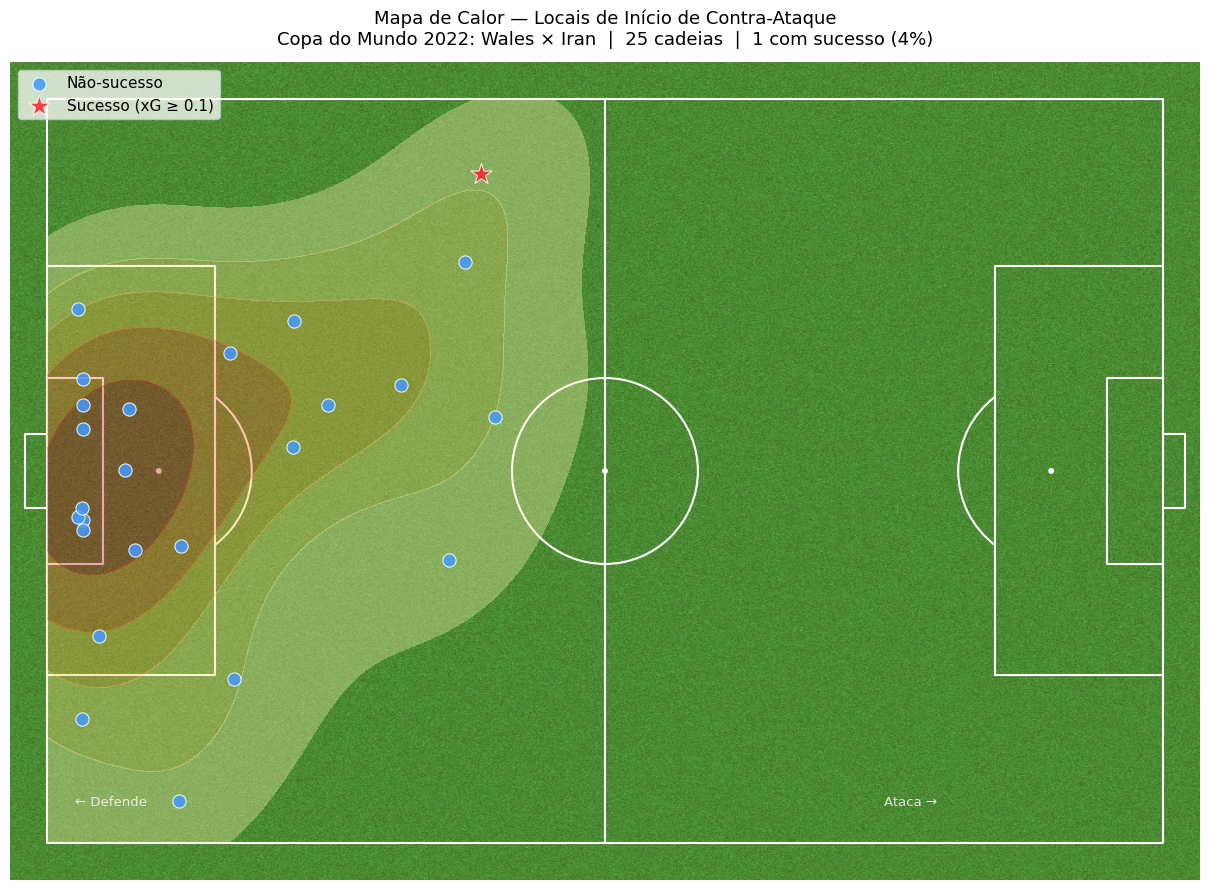

Figura salva: viz1_mapa_calor_recuperacoes.png


In [14]:
# ============================================================
# VISUALIZAÇÃO 1: Mapa de calor dos inícios de contra-ataque
# ============================================================

fig, ax = plt.subplots(figsize=(14, 9))
pitch = Pitch(pitch_type='statsbomb', pitch_color='grass', line_color='white',
              linewidth=1.5, goal_type='box')
pitch.draw(ax=ax)

if len(df_dataset_final) > 0:
    x_all = df_dataset_final['x_inicio'].dropna().values
    y_all = df_dataset_final['y_inicio'].dropna().values
    if len(x_all) >= 3:
        pitch.kdeplot(x_all, y_all, ax=ax, cmap='YlOrRd', fill=True,
                     alpha=0.35, zorder=2, levels=6, thresh=0.05)

    for suc, cor, mrk, sz, lbl in [
        (False, '#4499ff', 'o', 90,  'Não-sucesso'),
        (True,  '#ff2222', '*', 250, f'Sucesso (xG ≥ {XG_THRESHOLD})'),
    ]:
        sub = df_dataset_final[df_dataset_final['sucesso'] == suc]
        if len(sub) > 0:
            ax.scatter(sub['x_inicio'], sub['y_inicio'],
                      c=cor, marker=mrk, s=sz, alpha=0.85, zorder=5,
                      edgecolors='white', linewidth=0.8, label=lbl)

    ax.legend(loc='upper left', fontsize=11, framealpha=0.75)
    n_suc = int(df_dataset_final['sucesso'].sum())
    n_tot = len(df_dataset_final)
    taxa  = n_suc / n_tot if n_tot > 0 else 0
    ax.set_title(
        f'Mapa de Calor — Locais de Início de Contra-Ataque\n'
        f'Copa do Mundo 2022: {home_team} × {away_team}  |  '
        f'{n_tot} cadeias  |  {n_suc} com sucesso ({taxa:.0%})',
        fontsize=13, pad=12)
    ax.annotate('← Defende', xy=(3, 76), fontsize=9.5, color='white', alpha=0.8)
    ax.annotate('Ataca →',   xy=(90, 76), fontsize=9.5, color='white', alpha=0.8)
else:
    ax.set_title('Sem dados para visualizar.')

plt.tight_layout()
plt.savefig('viz1_mapa_calor_recuperacoes.png', dpi=120, bbox_inches='tight')
plt.show()
print("Figura salva: viz1_mapa_calor_recuperacoes.png")

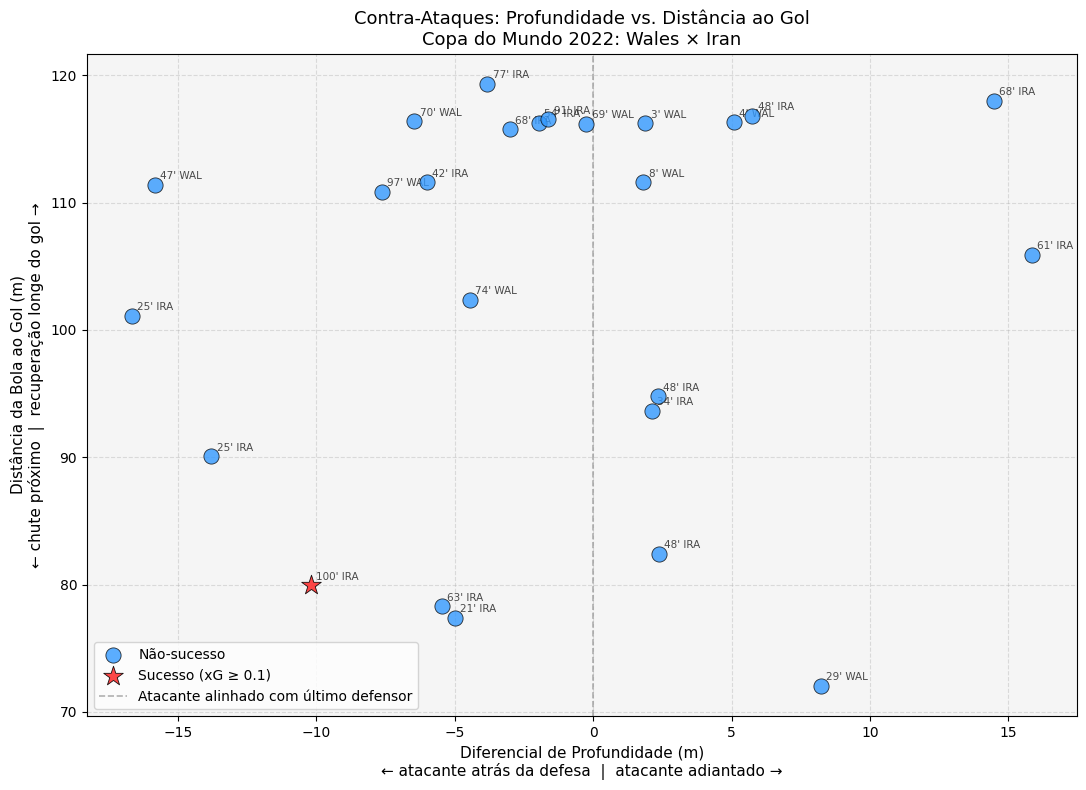

Figura salva: viz2_scatter_features.png


In [15]:
# ============================================================
# VISUALIZAÇÃO 2: Scatter — Profundidade vs. Distância ao Gol
# ============================================================

feat_x = 'diferencial_profundidade'
feat_y = 'dist_bola_gol'

fig, ax = plt.subplots(figsize=(11, 8))
ax.set_facecolor('#f5f5f5')
ax.grid(alpha=0.4, linestyle='--', linewidth=0.8)

if len(df_dataset_final) > 0:
    # Não-sucesso
    sub0 = df_dataset_final[df_dataset_final['sucesso'] == False]
    if len(sub0) > 0:
        ax.scatter(sub0[feat_x], sub0[feat_y],
                  c='#3399ff', s=120, alpha=0.8, edgecolors='black',
                  linewidth=0.6, label='Não-sucesso', zorder=4)
    # Sucesso
    sub1 = df_dataset_final[df_dataset_final['sucesso'] == True]
    if len(sub1) > 0:
        ax.scatter(sub1[feat_x], sub1[feat_y],
                  c='#ff3333', s=220, alpha=0.9, marker='*',
                  edgecolors='black', linewidth=0.6,
                  label=f'Sucesso (xG ≥ {XG_THRESHOLD})', zorder=5)

    # Anotações com minuto e equipe
    for _, row in df_dataset_final.iterrows():
        if not pd.isna(row.get(feat_x)) and not pd.isna(row.get(feat_y)):
            abbr = row['team'].split()[0][:3].upper()
            ax.annotate(f"{int(row['minute'])}' {abbr}",
                       (row[feat_x], row[feat_y]),
                       fontsize=7.5, alpha=0.7, ha='left',
                       xytext=(4, 4), textcoords='offset points')

    ax.axvline(0, color='gray', linestyle='--', alpha=0.6, lw=1.2,
              label='Atacante alinhado com último defensor')

    ax.set_xlabel(
        'Diferencial de Profundidade (m)\n'
        '← atacante atrás da defesa  |  atacante adiantado →', fontsize=11)
    ax.set_ylabel(
        'Distância da Bola ao Gol (m)\n'
        '← chute próximo  |  recuperação longe do gol →', fontsize=11)
    ax.set_title(
        f'Contra-Ataques: Profundidade vs. Distância ao Gol\n'
        f'Copa do Mundo 2022: {home_team} × {away_team}', fontsize=13)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('viz2_scatter_features.png', dpi=120, bbox_inches='tight')
plt.show()
print("Figura salva: viz2_scatter_features.png")

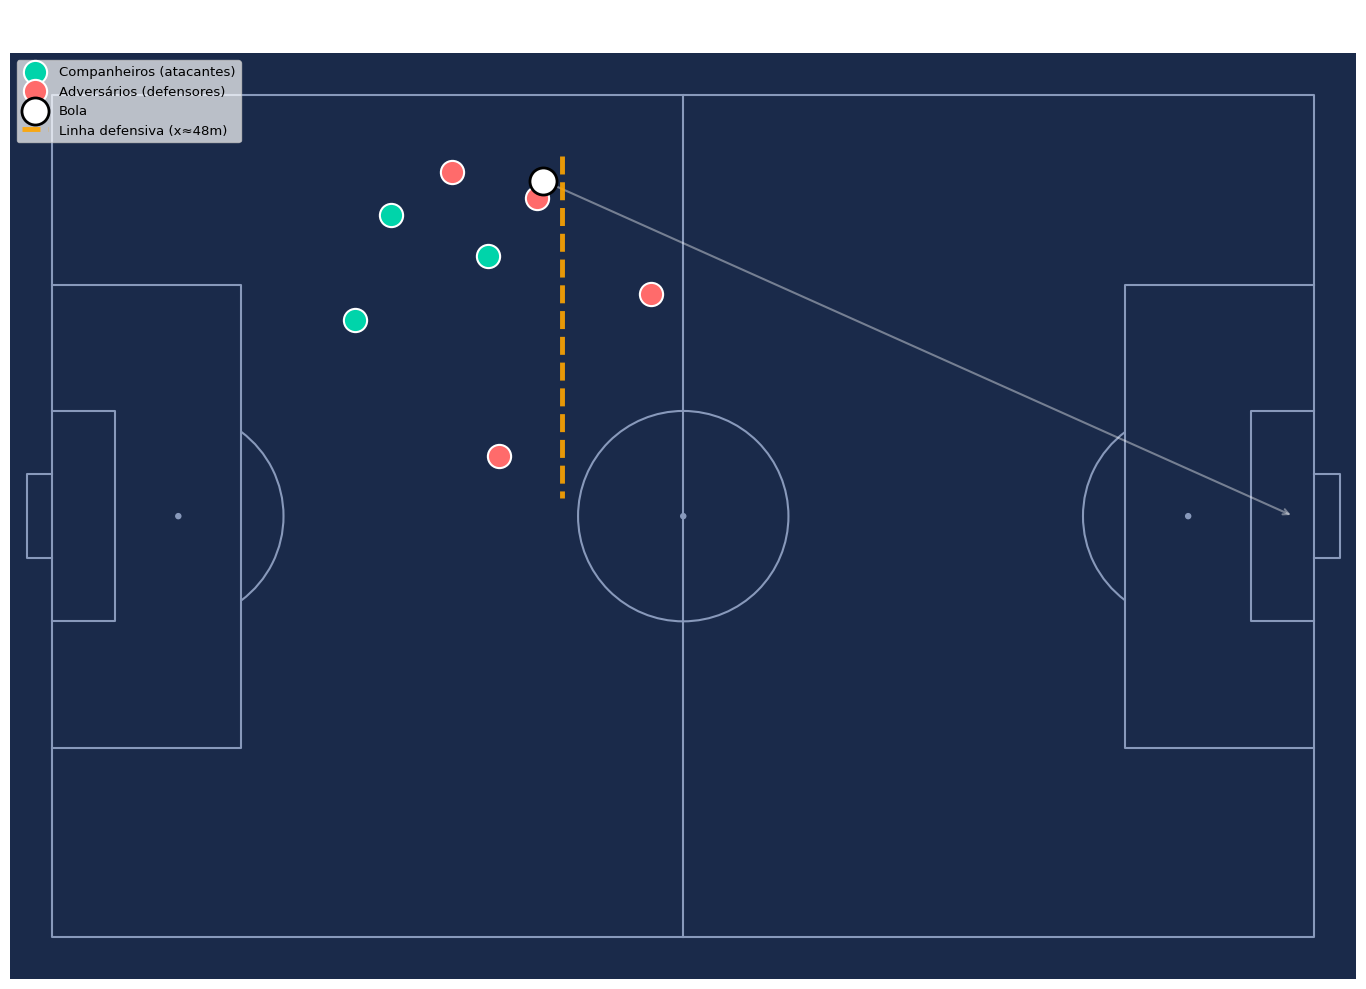

Figura salva: viz3_freeze_frame_ca.png

Detalhes do CA visualizado:
  player_name                                Mehdi Taremi
  team                                       Iran
  period                                     2
  minute                                     100
  tipo_inicio                                Ball Recovery
  progressao_x                               73.30
  dist_bola_gol                              79.94
  diferencial_profundidade                   -10.20
  num_defensores_entre_bola_gol              1
  superioridade_terco_ofensivo               0
  pace_atacante                              13
  pace_defensor                              13.00
  diferencial_pace                           0.00
  xg_final                                   0.20
  sucesso                                    True


In [16]:
# ============================================================
# VISUALIZAÇÃO 3: Freeze Frame 360 de um contra-ataque
# ============================================================
# Seleciona o CA mais interessante (sucesso primeiro, depois o mais adiantado)

if len(df_dataset_final) == 0:
    print("Sem contra-ataques para visualizar.")
else:
    ca_viz_df = df_dataset_final.sort_values(
        ['sucesso', 'diferencial_profundidade'], ascending=[False, False])
    ca_viz       = ca_viz_df.iloc[0]
    event_id_viz = ca_viz['id_inicio']
    frame_viz    = df_360[df_360["id"] == event_id_viz].copy()
    ev_viz       = df_event[df_event["id"] == event_id_viz].iloc[0]

    fig, ax = plt.subplots(figsize=(15, 10))
    pitch = Pitch(pitch_type='statsbomb', pitch_color='#1a2a4a',
                  line_color='#8899bb', linewidth=1.5, goal_type='box')
    pitch.draw(ax=ax)

    if len(frame_viz) > 0:
        tm = frame_viz[frame_viz["teammate"] == True]
        op = frame_viz[frame_viz["teammate"] == False]

        # Companheiros (atacantes no CA) — verde-água
        pitch.scatter(tm["x"], tm["y"],
                     c='#00d4aa', s=280, edgecolors='white', linewidth=1.5,
                     ax=ax, zorder=5, label='Companheiros (atacantes)')

        # Adversários (defensores) — vermelho
        pitch.scatter(op["x"], op["y"],
                     c='#ff6b6b', s=280, edgecolors='white', linewidth=1.5,
                     ax=ax, zorder=5, label='Adversários (defensores)')

        # Goleiros: marcados com quadrado
        gk = frame_viz[frame_viz["keeper"] == True]
        if len(gk) > 0:
            pitch.scatter(gk["x"], gk["y"],
                         c='yellow', s=320, edgecolors='black', linewidth=1.5,
                         marker='s', ax=ax, zorder=6, label='Goleiro')

        # Bola
        bola_x = float(ev_viz.get("x", 60))
        bola_y = float(ev_viz.get("y", 40))
        pitch.scatter([bola_x], [bola_y],
                     c='white', s=380, edgecolors='black', linewidth=2,
                     marker='o', ax=ax, zorder=7, label='Bola')

        # Linha defensiva: 3 defensores mais avançados
        top3 = op.nlargest(min(3, len(op)), "x")
        if len(top3) >= 2:
            x_linha = float(top3["x"].mean())
            y_min   = float(top3["y"].min()) - 4
            y_max   = float(top3["y"].max()) + 4
            ax.plot([x_linha, x_linha], [y_min, y_max],
                   color='orange', lw=3.5, linestyle='--', alpha=0.9,
                   zorder=4, label=f'Linha defensiva (x≈{x_linha:.0f}m)')

        # Seta da bola ao gol (indicativa)
        ax.annotate('', xy=(GOAL_X - 2, GOAL_Y),
                   xytext=(bola_x, bola_y),
                   arrowprops=dict(arrowstyle='->', color='white', lw=1.5, alpha=0.4))

    suc_str = "✓ SUCESSO" if ca_viz['sucesso'] else "✗ Sem finalização de qualidade"
    titulo = (f"Freeze Frame 360 — Início de Contra-Ataque\n"
              f"{ca_viz['team']} | {int(ca_viz['minute'])}'{int(ca_viz['second']):02d}\" | "
              f"Tipo: {ca_viz['tipo_inicio']} | "
              f"Progressão: {ca_viz['progressao_x']:.0f}m | {suc_str}")
    ax.set_title(titulo, fontsize=11.5, color='white', pad=10)
    ax.legend(loc='upper left', fontsize=9.5, framealpha=0.7)

    plt.tight_layout()
    plt.savefig('viz3_freeze_frame_ca.png', dpi=120, bbox_inches='tight')
    plt.show()
    print("Figura salva: viz3_freeze_frame_ca.png")
    print(f"\nDetalhes do CA visualizado:")
    for col in ['player_name', 'team', 'period', 'minute', 'tipo_inicio',
                'progressao_x', 'dist_bola_gol', 'diferencial_profundidade',
                'num_defensores_entre_bola_gol', 'superioridade_terco_ofensivo',
                'pace_atacante', 'pace_defensor', 'diferencial_pace',
                'xg_final', 'sucesso']:
        if col in ca_viz.index:
            v = ca_viz[col]
            if isinstance(v, float):
                print(f"  {col:<42} {v:.2f}")
            else:
                print(f"  {col:<42} {v}")

## Demonstração — Análise de Sensibilidade

Rodamos `rodar_analise_sensibilidade` com **4 configurações distintas** numa mesma
partida (País de Gales × Irã) para ilustrar como as escolhas de definição afetam
o número de contra-ataques identificados e a taxa de sucesso.

| # | Descrição | Zona | Eventos | Tempo | Progressão mín. |
|---|-----------|------|---------|-------|-----------------|
| 1 | **Base** (reproduz o original) | metade defensiva | 5 | 15s | 30m |
| 2 | **Ampla** | campo todo | 10 | 25s | 30m |
| 3 | **Restrita** | terço defensivo | 5 | 10s | 30m |
| 4 | **Sem filtro de progressão** | metade defensiva | 7 | 15s | 0m |


In [17]:
# ============================================================
# DEMONSTRAÇÃO: Análise de Sensibilidade com 4 configurações
# ============================================================

# Config 1 — Base: reproduz o comportamento original do notebook
cfg_base = {
    **config,
}

# Config 2 — Ampla: sem restrição de zona, mais eventos e mais tempo
cfg_ampla = {
    **config,
    "zona_recuperacao":       "campo_todo",
    "max_eventos_apos":       10,
    "max_tempo_s":            25,
}

# Config 3 — Restrita: apenas terço defensivo, janela de tempo menor
cfg_restrita = {
    **config,
    "zona_recuperacao":  "terco_defensivo",
    "max_eventos_apos":  5,
    "max_tempo_s":       10,
}

# Config 4 — Sem filtro de progressão: captura qualquer ação rápida
cfg_sem_prog = {
    **config,
    "zona_recuperacao":          "metade_defensiva",
    "max_eventos_apos":          7,
    "progressao_vertical_min_m": 0,
}

lista_configs_demo = [cfg_base, cfg_ampla, cfg_restrita, cfg_sem_prog]
match_ids_demo     = [MATCH_ID]  # mesma partida para comparação direta

print("Rodando análise de sensibilidade...")
df_sensib = rodar_analise_sensibilidade(lista_configs_demo, match_ids_demo)

print("\n=== Tabela Comparativa — Análise de Sensibilidade ===")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
print(df_sensib.to_string(index=False))


Rodando análise de sensibilidade...



=== Tabela Comparativa — Análise de Sensibilidade ===
 config_idx zona_recuperacao  max_eventos  max_tempo_s  prog_min_m criterio_sucesso  n_contra_ataques  n_sucessos  taxa_sucesso  duracao_media_s
          0 metade_defensiva            5           15          30     xg_threshold                26           1        0.0385             6.85
          1       campo_todo           10           25          30     xg_threshold                38           1        0.0263             8.39
          2  terco_defensivo            5           10          30     xg_threshold                19           0        0.0000             5.74
          3 metade_defensiva            7           15           0     xg_threshold                86           1        0.0116             3.55


### Interpretação da tabela de sensibilidade

A tabela acima revela **o quanto os resultados dependem das escolhas de definição**,
não apenas dos dados:

- **Config Base vs. Ampla:** ao remover a restrição de zona e ampliar a janela de eventos
  e tempo, o número de contra-ataques identificados tende a aumentar substancialmente —
  muitas recuperações longe do campo defensivo também geram transições rápidas.

- **Config Restrita:** exigir que a recuperação ocorra no terço defensivo reduz o conjunto
  drasticamente; esses contra-ataques são os mais "puros" (contra-ataques de defesa
  baixa), mas representam uma fração pequena do total.

- **Sem filtro de progressão:** ao zerá-lo, capturamos trocas rápidas de posse sem
  progressão real — o número de "contra-ataques" dispara, mas a taxa de sucesso cai,
  pois a maioria desses eventos não culmina em ameaça real.

> **Conclusão metodológica:** qualquer métrica de contra-ataque é uma *escolha*, não
> uma verdade. A análise de sensibilidade quantifica essa incerteza e deve ser reportada
> junto com os resultados do modelo para garantir robustez e transparência.


## Próximos Passos

Esta PoC valida o pipeline com **uma partida** (~10–20 cadeias). Para transformar em modelo publicável:

### (a) Escalar para as mais partidas

```python
parser = Sbopen()
df_match = parser.match(competition_id=43, season_id=106)
datasets = []
for _, row in df_match.iterrows():
    df_ev, _, _, df_tact = parser.event(row['match_id'])
    df_360_j, _          = parser.frame(row['match_id'])
    cas     = identificar_contra_ataques(df_ev)
    feat_l  = [extrair_features_espaciais(ca['id_inicio'], df_ev, df_360_j)
               for ca in cas]
    df_j = pd.DataFrame(cas).merge(
        pd.DataFrame(feat_l).rename(columns={'event_id':'id_inicio'}), on='id_inicio')
    datasets.append(df_j)
df_completo = pd.concat(datasets, ignore_index=True)
# Espera-se ~800–1500 cadeias — volume adequado para treino/teste
```

### (b) Refinar identificação do defensor

Implementar o matching posição × freeze frame: encontrar o oponente com maior `x`
**no próprio freeze frame** e cruzar com a lineup do período via `df_event`
(events de tipo `"Substitution"` marcam mudanças na escalação) ou implementar um valor como defesa média, usando os status do FM.

### (c) Implementar o modelo com XGBoost e análise SHAP

```python
import xgboost as xgb
import shap
model_xgb = xgb.XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                                scale_pos_weight=len(y_train)//y_train.sum())
model_xgb.fit(X_train, y_train)
explainer = shap.TreeExplainer(model_xgb)
shap_vals = explainer.shap_values(X_test)
shap.summary_plot(shap_vals, X_test, feature_names=FEATURES_COMPLETAS)
```

### (d) Split treino/teste adequado

```python
from sklearn.model_selection import StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Ou split temporal: treino = fase de grupos, teste = eliminatórias
```

### (e) Análise de ablação (hipótese central do trabalho)

Treinar dois modelos com mais partidas:
- **M1 (Espacial):** apenas features do freeze frame 360
- **M2 (Espacial + FM):** M1 + atributos físicos do FM2023

Comparar AUC-ROC dos dois modelos:
```python
from scipy.stats import permutation_test
# Teste de permutação: H0 = AUC(M1) == AUC(M2)
```

Se Δ(AUC) > 0 com p < 0.05, a hipótese é confirmada: **features físicas estáticas do FM
contribuem poder preditivo incremental ao xCounter**.

---
*Notebook criado para COE609 (UFRJ, 2026.1).*
*Dados: StatsBomb Open Data (Copa do Mundo FIFA 2022) + Football Manager 2023 Database.*